# SAFOD AWD weight drops — node timing → DAS detection

**June 2026 active-source survey.** 2026-06-16 23:47 → 2026-06-17 23:47 UTC
(24.0 h) · local 2026-06-16 16:47 → 2026-06-17 16:47 PDT.

**The survey: 20 weight drops every 30 minutes, around the clock for 24 hours.**
Measured from the delivered picks — 49 bursts, median gap 30.0 min (range
27.6–31.2), 20 drops in 36 of the 49 bursts (19–23 overall), drops 9.0 s apart
within a burst, 171 s per burst, **989 drops** in total.

This notebook shows **which of those drops we detected in the DAS, and how we
found them**. It reads the finished products by default and re-runs nothing, so
it opens in a couple of seconds.

## How to use it

One switch, in the next code cell:

| `REBUILD_PRODUCTS` | What happens |
|---|---|
| `False` *(default)* | load `awd_drop_catalog.csv` etc. and plot. Seconds. |
| `True` | re-run `build_drop_catalog.py` from the node picks first, then plot. Needs the raw `Check shots/` files on disk. |

Set it to `True` only to verify the products regenerate. The plots are identical
either way — that is the point of the switch.

## Provenance — what we did and did not do

**The 989 drop times were delivered to us.** They are cross-correlation picks
made on two standalone seismic nodes, `p26.cc9.txt` (node 453009664) and
`p26.cc4.txt` (node 453001432), ~10–20 m apart. No script in this repository
produces them.

**Our work is everything downstream:** validating that timing against the second
node, intersecting it with DAS file coverage, and then testing whether each drop
is actually *detectable* in each fibre.

> **Coverage is not detection.** A drop falling inside a DAS file only means the
> recorder was running. Whether the drop is *in* the data is a separate
> measurement, and it is the one this notebook reports.

## 1. Configuration

The one switch, plus which drops the example figures use.

In [1]:
# ------------------------------------------------------------------ #
#  THE SWITCH.  False = load finished products (fast, the default).   #
#               True  = regenerate them from the node picks first.    #
# ------------------------------------------------------------------ #
REBUILD_PRODUCTS = False

# Which drops the example figures show. Change freely -- nothing downstream
# depends on these; they are illustrative only.
EXAMPLE_BURST = 0        # burst shown raw in Figure 1 and drop-by-drop in Figure 6
N_EXAMPLE_DROPS = 6      # individual drops overlaid in Figure 5

In [2]:
import subprocess, sys, os, csv, datetime as dt
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

HERE = Path("__file__" in dir() and __file__ or ".").resolve().parent
if HERE.name != "drop_catalog":                      # notebook cwd fallback
    HERE = Path.cwd()
    if HERE.name != "drop_catalog":
        HERE = HERE / "awd_clean" / "drop_catalog"
AWD = HERE.parent

# Validated categorical palette (dataviz reference instance, light mode).
# Slots 1 and 2 pass all six checks as a pair: CVD dE 24.7, normal-vision 33.6.
BLUE, ORANGE = "#2a78d6", "#eb6834"   # detected / not detected
RED = "#e34948"                       # drop-time marker (annotation, not a series)
INK, INK2 = "#0b0b0b", "#52514e"      # text: never the series colour
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#d8d7d2", "axes.linewidth": 0.8,      # recessive axes
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2,
    "ytick.color": INK2, "font.size": 10, "axes.titlesize": 11,
    "legend.frameon": False, "figure.dpi": 120,
})
print("matplotlib backend:", plt.get_backend())

matplotlib backend: module://matplotlib_inline.backend_inline


## 2. Load the products

With `REBUILD_PRODUCTS = True` this shells out to `build_drop_catalog.py`, which
re-reads the two node pick files and the DAS manifest and rewrites all three
products. Otherwise the existing CSVs are read straight off disk.

In [3]:
if REBUILD_PRODUCTS:
    print("REBUILD_PRODUCTS = True -- regenerating from the node picks ...\n")
    r = subprocess.run([sys.executable, str(HERE / "build_drop_catalog.py")],
                       capture_output=True, text=True)
    print(r.stdout[-2000:] or r.stderr[-2000:])
    if r.returncode != 0:
        raise RuntimeError("build_drop_catalog.py failed -- see output above")
else:
    print("REBUILD_PRODUCTS = False -- loading the committed products.")

catalog = list(csv.DictReader((HERE / "awd_drop_catalog.csv").open()))
bursts  = list(csv.DictReader((HERE / "awd_burst_summary.csv").open()))
print(f"  {len(catalog)} drops, {len(bursts)} bursts")

def f(row, key):
    """Float from a catalogue cell, or nan when the field is blank."""
    v = row.get(key, "")
    return float(v) if v not in ("", None) else np.nan

times   = np.array([dt.datetime.fromisoformat(r["utc_time"]) for r in catalog])
covered = np.array([r["nano_covered"] == "1" for r in catalog])
detected = np.array([r["nano_detected"] == "1" for r in catalog])
snr     = np.array([f(r, "nano_beam_snr_db") for r in catalog])
ncc     = np.array([f(r, "nano_loo_signal_ncc") for r in catalog])

REBUILD_PRODUCTS = False -- loading the committed products.
  989 drops, 49 bursts


## 3. The numbers

Coverage, then detection. The gap between the two columns is the point.

In [4]:
n = len(catalog)
span_h = (times.max() - times.min()).total_seconds() / 3600
print(f"survey span      : {times.min():%Y-%m-%d %H:%M} -> {times.max():%Y-%m-%d %H:%M} UTC"
      f"  ({span_h:.1f} h)")
print(f"                 : {times.min() - dt.timedelta(hours=7):%Y-%m-%d %H:%M} -> "
      f"{times.max() - dt.timedelta(hours=7):%Y-%m-%d %H:%M} local PDT")
print(f"delivered picks  : {n}")
print(f"bursts           : {len(bursts)}")
print()
print(f"{'':22s}{'count':>7s}{'share':>9s}")
for label, mask in [("Nano coverage", covered),
                    ("Deep coverage", np.array([r['deep_covered'] == '1' for r in catalog])),
                    ("both fibres",   np.array([r['paired_covered'] == '1' for r in catalog])),
                    ("NANO DETECTED",  detected)]:
    print(f"{label:22s}{mask.sum():7d}{mask.sum()/n:9.1%}")
print()
ok = np.isfinite(snr)
print(f"Nano beam SNR    : median {np.median(snr[ok]):.1f} dB, "
      f"90th pct {np.percentile(snr[ok], 90):.1f} dB")
print(f"Nano LOO sig NCC : median {np.median(ncc[ok]):.3f}")
print()
print("--- two-node timing agreement (timing_uncertainty.txt) ---")
for line in (HERE / "timing_uncertainty.txt").read_text().splitlines():
    if line.startswith(("median offset", "MAD", "5th / 95th")):
        print(line)

survey span      : 2026-06-16 23:47 -> 2026-06-17 23:47 UTC  (24.0 h)
                 : 2026-06-16 16:47 -> 2026-06-17 16:47 local PDT
delivered picks  : 989
bursts           : 49

                        count    share
Nano coverage             988    99.9%
Deep coverage             926    93.6%
both fibres               926    93.6%
NANO DETECTED             409    41.4%

Nano beam SNR    : median 7.7 dB, 90th pct 25.7 dB
Nano LOO sig NCC : median 0.889

--- two-node timing agreement (timing_uncertainty.txt) ---
median offset            : -1.00 ms
MAD                      : 0.50 ms
5th / 95th percentile    : -2.50 / +0.50 ms


## 4. Figure 1 — six bursts as recorded, with every drop marked

**This is the plain look.** Continuous Nano record through each of six bursts —
not windowed, not re-zeroed, just the trace running in real time — with a **red
dotted line at every delivered drop time**. ~20 drops and ~20 marks per panel,
about 9 s apart.

Every other figure below windows each drop and re-zeroes it on its own pick,
which is right for stacking but puts exactly one mark in each panel. These keep
absolute time so the marks and the impulses can be seen together.

**Six bursts, not one, because detection is strongly time-varying.** The panels
are sampled across the full 24 hours, and they do not look alike: burst 30 has
**0 of 20** drops detected on Nano while burst 48 has **16 of 20**. Any single
burst would misrepresent the survey.

The trace is the 30–60 Hz beam over 81–439 m of fibre at 2,975 m/s — the same
beam the detection metrics use. All panels share one time axis, measured from
each burst's own first drop.

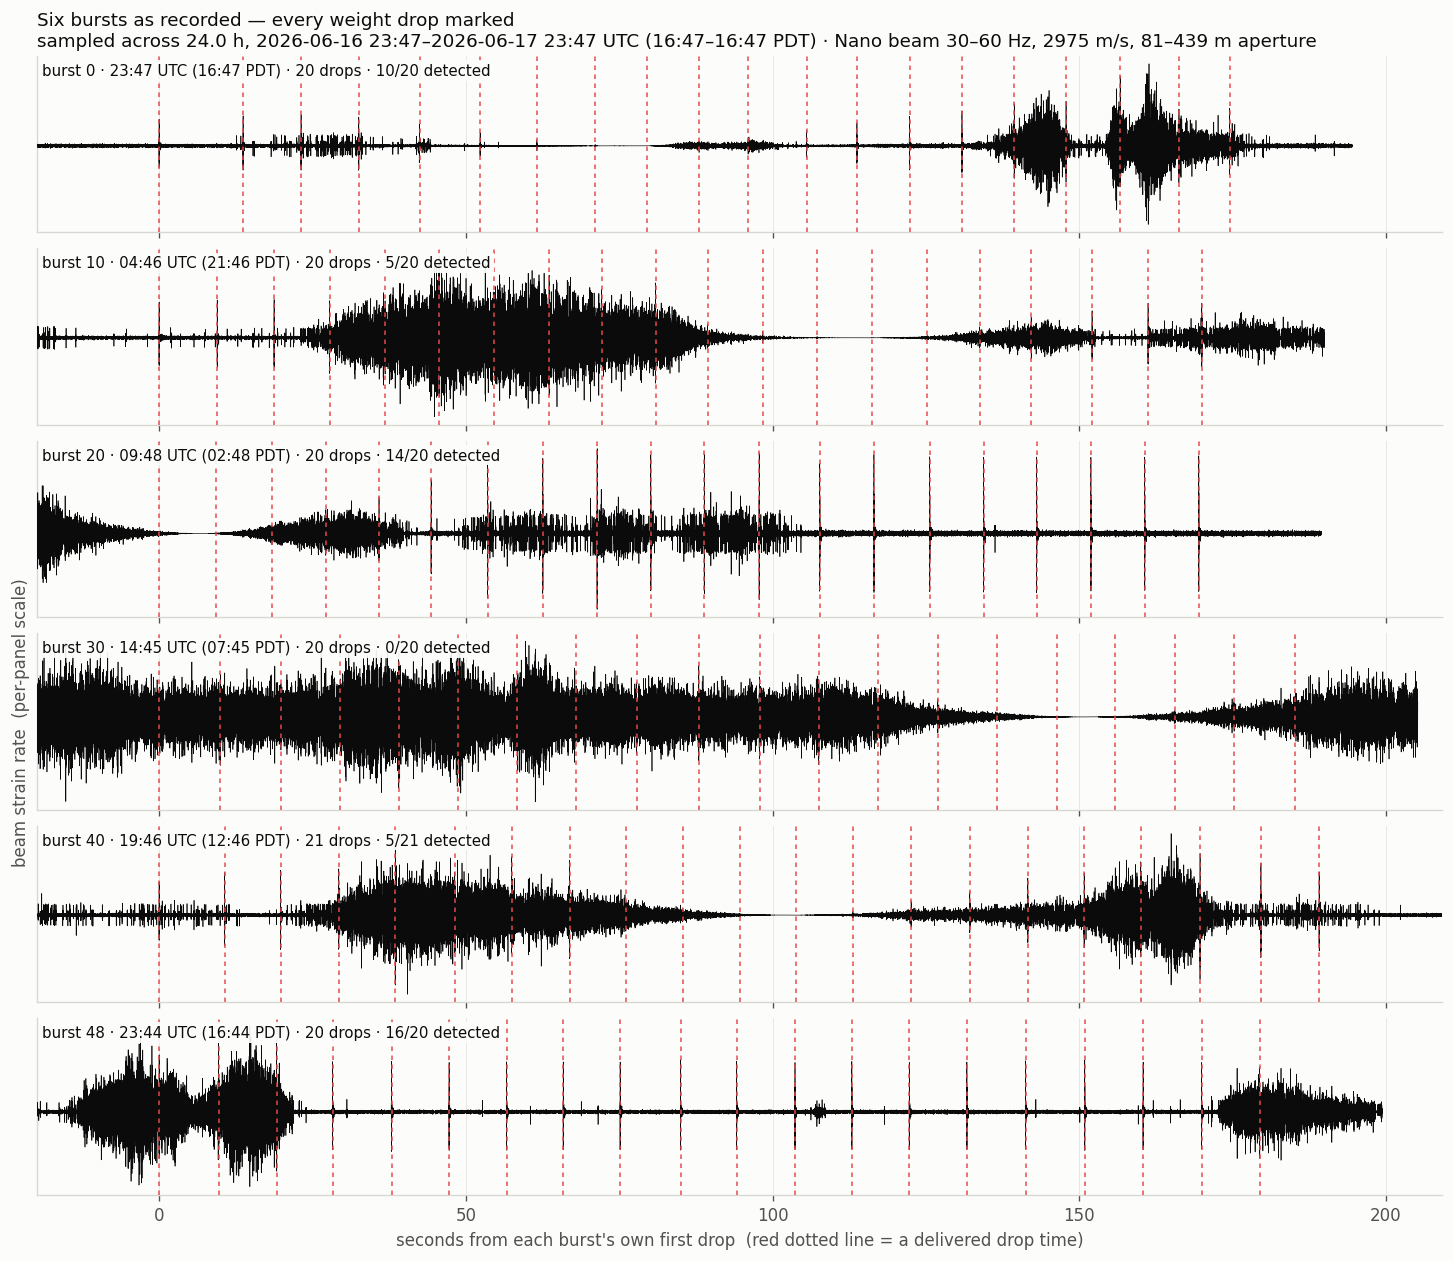

In [5]:
BT = HERE / "burst_timeseries.npz"
if REBUILD_PRODUCTS or not BT.exists():
    print("extracting the continuous burst records from $OAK ...")
    r = subprocess.run([sys.executable, str(HERE / "build_burst_timeseries.py")],
                       capture_output=True, text=True, env=os.environ)
    print(r.stdout[-1500:] or r.stderr[-1500:])
    if r.returncode != 0:
        raise RuntimeError("build_burst_timeseries.py failed -- see above")

b = np.load(BT, allow_pickle=True)
blist = list(b["bursts"])
bband, bv = b["band_hz"], float(b["velocity_mps"])
bap = b["aperture_m"]

# detected-count per burst, straight from the burst summary
det = {int(r["burst_id"]): (int(r["n_nano_detected"]), int(r["n_drops"]))
       for r in bursts}

fig, axes = plt.subplots(len(blist), 1, figsize=(12, 1.55 * len(blist) + 1.1),
                         sharex=True, constrained_layout=True)
axes = np.atleast_1d(axes)

for ax, bn in zip(axes, blist):
    t_rel = b[f"b{bn}_t_rel"]
    tr = b[f"b{bn}_trace"]
    d_rel = b[f"b{bn}_drop_rel"]
    t0 = dt.datetime.fromisoformat(str(b[f"b{bn}_start_utc"]))

    ax.plot(t_rel, tr, color=INK, lw=0.4, zorder=3)
    for d in d_rel:
        ax.axvline(d, color=RED, lw=0.9, ls=(0, (3, 3)), zorder=4)

    nd, nt = det.get(int(bn), (0, len(d_rel)))
    # opaque box: several panels are dense enough that bare text is unreadable
    ax.annotate(f"burst {int(bn)} · {t0:%H:%M} UTC ({t0 - dt.timedelta(hours=7):%H:%M} PDT)"
                f" · {len(d_rel)} drops · {nd}/{nt} detected",
                (0.004, 0.96), xycoords="axes fraction", va="top",
                color=INK, fontsize=9, zorder=6,
                bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.6, alpha=0.92))
    ax.set_yticks([])
    ax.margins(x=0)
    ax.grid(axis="y", visible=False)

axes[-1].set_xlabel("seconds from each burst's own first drop  "
                    "(red dotted line = a delivered drop time)")
axes[len(axes) // 2].set_ylabel("beam strain rate  (per-panel scale)")
axes[0].set_title(
    f"Six bursts as recorded — every weight drop marked\n"
    f"sampled across 24.0 h, 2026-06-16 23:47–2026-06-17 23:47 UTC "
    f"(16:47–16:47 PDT) · Nano beam {bband[0]:.0f}–{bband[1]:.0f} Hz, "
    f"{bv:.0f} m/s, {bap[0]:.0f}–{bap[1]:.0f} m aperture",
    color=INK, loc="left")
plt.show()

## 5. Figure 2 — every drop across the survey

One mark per drop, over the full 24 h. The 49 bursts show up as clusters. Colour
is Nano detection, so the vertical structure is where in the survey the source
was actually getting into the fibre.

Detection = leave-one-out signal NCC > 0.90 **and** beam SNR > 10 dB. Those
thresholds are descriptive, not pre-registered — see the caveats at the end.

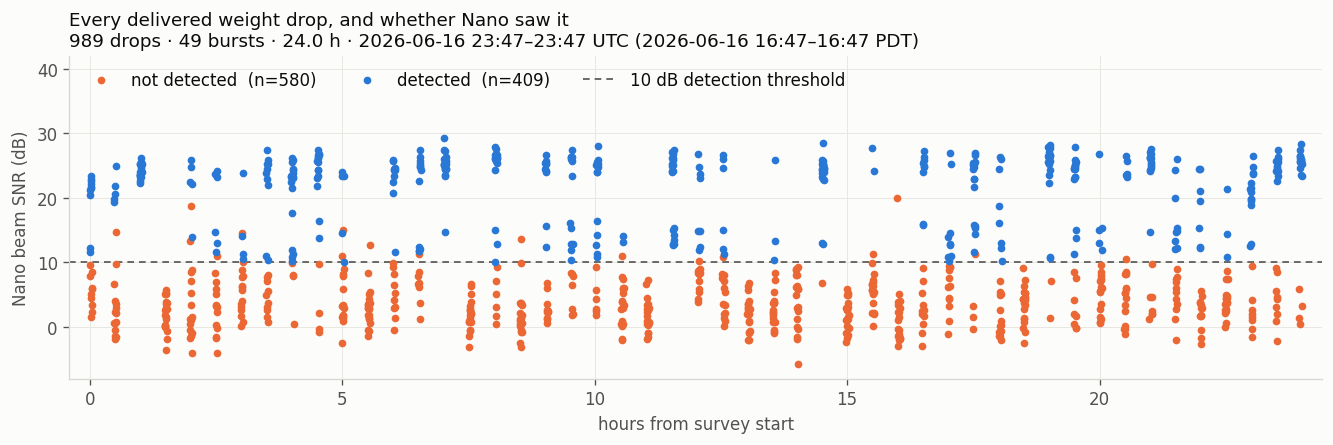

In [6]:
fig, ax = plt.subplots(figsize=(11, 3.6), constrained_layout=True)
h = np.array([(t - times.min()).total_seconds() / 3600 for t in times])

ax.scatter(h[~detected], snr[~detected], s=13, c=ORANGE,
           label=f"not detected  (n={int((~detected).sum())})", zorder=3)
ax.scatter(h[detected], snr[detected], s=13, c=BLUE,
           label=f"detected  (n={int(detected.sum())})", zorder=4)
# The threshold goes in the legend, not as an inline annotation: at this density
# there is no gap in the data big enough to place text without a collision.
ax.axhline(10, color=INK2, lw=1.0, ls=(0, (4, 3)), zorder=2,
           label="10 dB detection threshold")

ax.set_xlabel("hours from survey start")
ax.set_ylabel("Nano beam SNR (dB)")
ax.set_xlim(-0.4, span_h + 0.4)
# Headroom above the data (max ~30 dB) so the legend sits in clear space.
ax.set_ylim(min(-8, np.nanmin(snr) - 2), 42)
ax.legend(loc="upper left", ncols=3)
ax.set_title("Every delivered weight drop, and whether Nano saw it\n"
             f"{len(catalog)} drops · {len(bursts)} bursts · {span_h:.1f} h · "
             f"{times.min():%Y-%m-%d %H:%M}–{times.max():%H:%M} UTC "
             f"({times.min() - dt.timedelta(hours=7):%Y-%m-%d %H:%M}–"
             f"{times.max() - dt.timedelta(hours=7):%H:%M} PDT)",
             color=INK, loc="left")
plt.show()

## 6. Figure 3 — the whole survey, every drop

**All 988 drops in one image**, in time order, top to bottom. Each row is one
drop's Nano beam waveform: the 30–60 Hz record shifted along a 2,975 m/s
trajectory and averaged over 81–439 m of fibre, from
`nano_hierarchical_repeatability.npz`.

The **red dotted line is the delivered node pick time**. The arrival is the
vertical stripe at about +130 ms — vertical means every drop across 24 hours
landed at the same time relative to its own pick, which is the whole case that
the delivered timing is usable.

The horizontal banding is real: it is the 49 bursts, and the bands where the
stripe fades are the hours when the source was not getting into the fibre. That
is the same structure Figure 1 shows as colour.

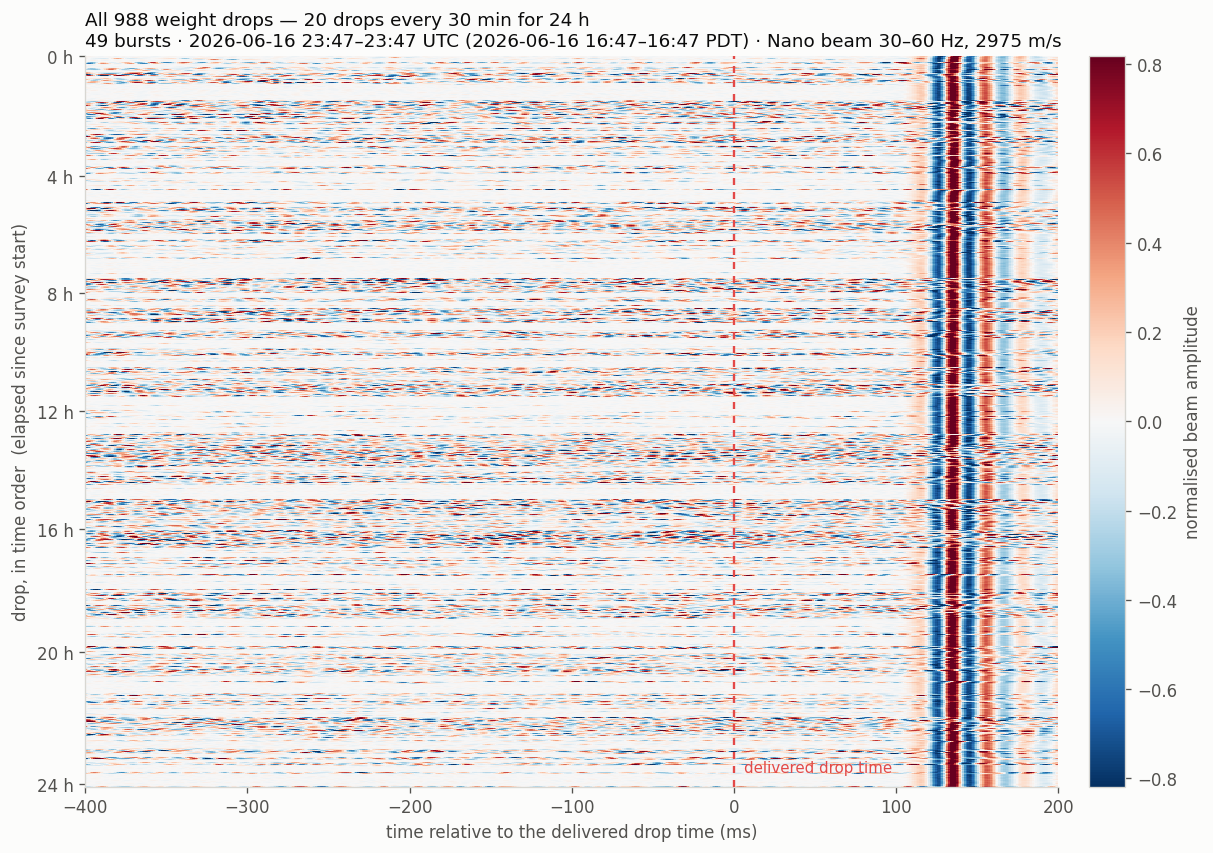

In [7]:
z = np.load(AWD / "nano_hierarchical_repeatability.npz", allow_pickle=True)
tau, beams = z["tau_s"], z["beam_waveforms"]
bid, did = z["burst_id"], z["drop_id"]
btmp = z["normalized_burst_templates"]
v, band = float(z["velocity_mps"]), z["band_hz"]
ap = z["aperture_m"]

# The npz holds the 988 drops that entered the manifest; `times` above holds all
# 989 delivered picks. Use the npz's OWN timestamps so the two never mis-align --
# slicing `times[:988]` would silently shift every row if the missing pick were
# not the last one.
btimes = np.array([dt.datetime.fromisoformat(s) for s in z["utc_date"]])
btimes = np.array([t.replace(tzinfo=None) for t in btimes])
assert len(btimes) == len(beams) == len(bid)

# SNR indexed the same way as the npz rows, joined on timestamp.
_snr_by_time = {t: v for t, v in zip(times, snr)}
bsnr = np.array([_snr_by_time.get(t, np.nan) for t in btimes])
assert np.isfinite(bsnr).sum() > 0.95 * len(bsnr), "SNR join failed"

allimg = beams / np.max(np.abs(beams), axis=1, keepdims=True)
lim = np.percentile(np.abs(allimg), 99)

fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
m = ax.imshow(allimg, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim,
              extent=[tau[0] * 1e3, tau[-1] * 1e3, len(allimg), 0],
              interpolation="nearest", zorder=2)
ax.axvline(0, color=RED, lw=1.4, ls=(0, (3, 3)), zorder=5)
# Label sits at the BOTTOM of the axes, inside: the pre-arrival region is pale
# there, and the top edge is taken by the two-line title.
ax.annotate("delivered drop time", xy=(0, 0), xycoords=("data", "axes fraction"),
            xytext=(6, 7), textcoords="offset points", color=RED, fontsize=9,
            va="bottom", ha="left")

# right-hand axis ticks in hours, so the 24 h is legible without a second scale
hh = np.array([(t - btimes.min()).total_seconds() / 3600 for t in btimes])
ticks = [int(np.argmin(np.abs(hh - q))) for q in range(0, 25, 4)]
ax.set_yticks(ticks)
ax.set_yticklabels([f"{int(round(hh[i]))} h" for i in ticks])
ax.set_ylabel("drop, in time order  (elapsed since survey start)")
ax.set_xlabel("time relative to the delivered drop time (ms)")
ax.grid(False)
fig.colorbar(m, ax=ax, pad=0.015, label="normalised beam amplitude")
ax.set_title(f"All {len(allimg)} weight drops — 20 drops every 30 min for 24 h\n"
             f"{len(np.unique(bid))} bursts · "
             f"{times.min():%Y-%m-%d %H:%M}–{times.max():%H:%M} UTC "
             f"({times.min() - dt.timedelta(hours=7):%Y-%m-%d %H:%M}–"
             f"{times.max() - dt.timedelta(hours=7):%H:%M} PDT) · "
             f"Nano beam {band[0]:.0f}–{band[1]:.0f} Hz, {v:.0f} m/s",
             color=INK, loc="left")
plt.show()

## 7. Figure 4 — the 49 bursts, stacked

The same data reduced to **one row per burst** — each is the 20-drop stack for
that burst, so this is the 24 hours at a glance without 988 rows of speckle.
Red dotted line is again the delivered drop time.

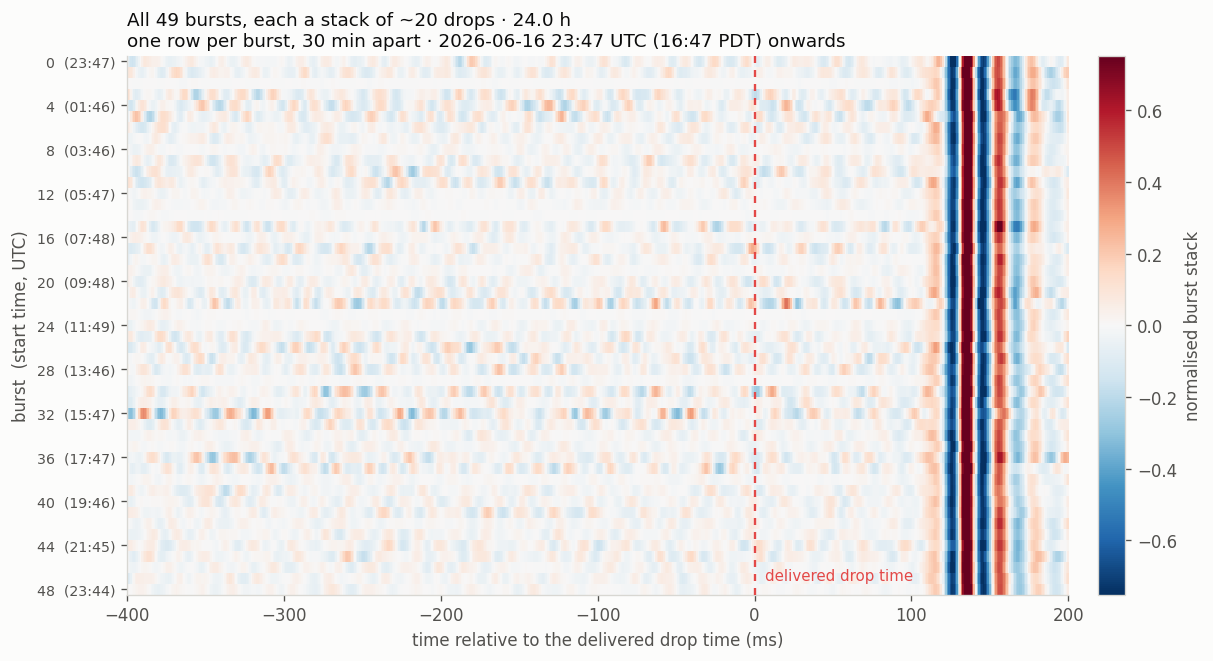

In [8]:
bt = btmp / np.max(np.abs(btmp), axis=1, keepdims=True)
lim2 = np.percentile(np.abs(bt), 99)
bstart = [btimes[bid == b].min() for b in range(len(bt))]

fig, ax = plt.subplots(figsize=(10, 5.4), constrained_layout=True)
m = ax.imshow(bt, aspect="auto", cmap="RdBu_r", vmin=-lim2, vmax=lim2,
              extent=[tau[0] * 1e3, tau[-1] * 1e3, len(bt) - 0.5, -0.5],
              interpolation="nearest", zorder=2)
ax.axvline(0, color=RED, lw=1.4, ls=(0, (3, 3)), zorder=5)
# Label sits at the BOTTOM of the axes, inside: the pre-arrival region is pale
# there, and the top edge is taken by the two-line title.
ax.annotate("delivered drop time", xy=(0, 0), xycoords=("data", "axes fraction"),
            xytext=(6, 7), textcoords="offset points", color=RED, fontsize=9,
            va="bottom", ha="left")
ax.set_yticks(range(0, len(bt), 4))
ax.set_yticklabels([f"{b}  ({bstart[b]:%H:%M})" for b in range(0, len(bt), 4)],
                   fontsize=8.5)
ax.set_ylabel("burst  (start time, UTC)")
ax.set_xlabel("time relative to the delivered drop time (ms)")
ax.grid(False)
fig.colorbar(m, ax=ax, pad=0.015, label="normalised burst stack")
ax.set_title(f"All {len(bt)} bursts, each a stack of ~20 drops · 24.0 h\n"
             f"one row per burst, 30 min apart · "
             f"{times.min():%Y-%m-%d %H:%M} UTC "
             f"({times.min() - dt.timedelta(hours=7):%H:%M} PDT) onwards",
             color=INK, loc="left")
plt.show()

## 8. Figure 5 — six drops close up

An **excerpt**, not the survey: six individual drops pulled from six different
bursts spread across the 24 hours, so the waveform is actually legible at trace
scale. Figures 3 and 4 are the complete picture; this is a zoom.

The **red dotted line is the delivered node pick time** — the drop time we were
given. Every trace is plotted on its own time axis relative to that pick. The
arrivals line up across drops recorded hours apart, which is what says the
delivered timing is good enough to stack on.

> The red line is the *node pick*, not the true source instant. Both nodes sit
> metres from the source and share the same unknown source-to-node travel time;
> the absolute offset is the ~90 ms measured against the check shot.

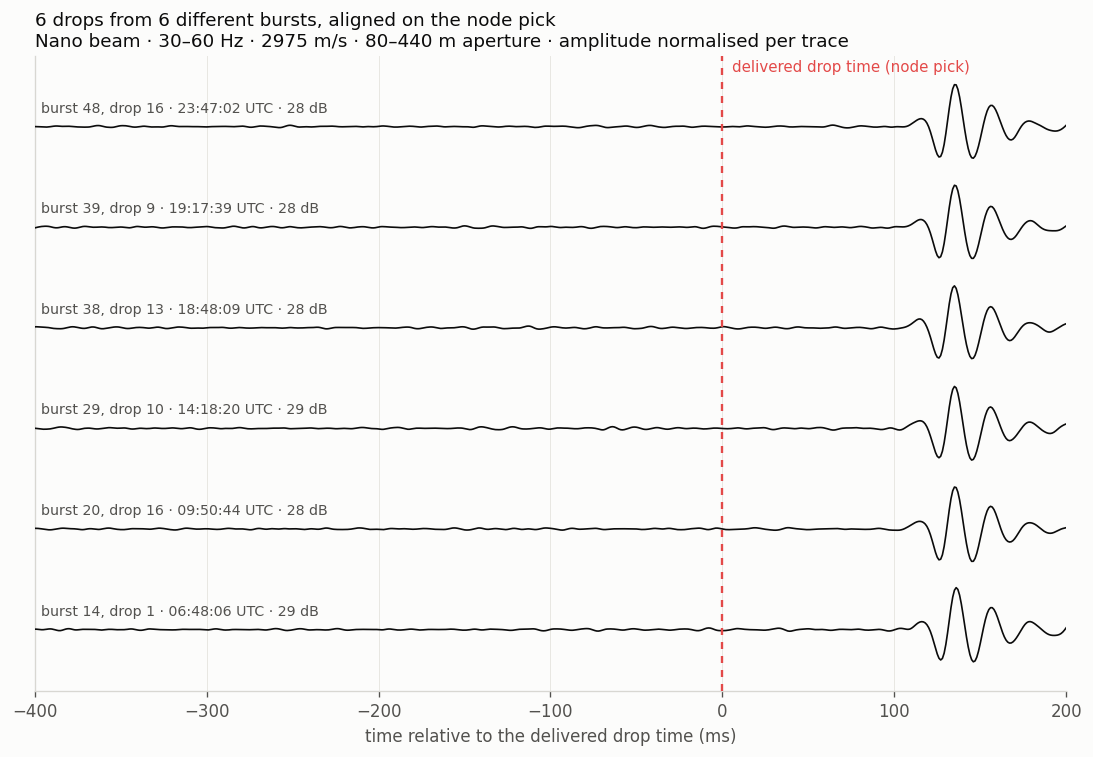

In [9]:
# Pick N drops spread across the whole survey, strongest-SNR first within reach.
order = np.argsort(-bsnr)
picked, seen = [], set()
for i in order:
    if bid[i] not in seen and np.isfinite(bsnr[i]):
        picked.append(i); seen.add(bid[i])
    if len(picked) == N_EXAMPLE_DROPS:
        break
picked = sorted(picked, key=lambda i: btimes[i])

fig, ax = plt.subplots(figsize=(9, 6.2), constrained_layout=True)
step = 2.4
for k, i in enumerate(picked):
    w = beams[i] / np.max(np.abs(beams[i]))
    ax.plot(tau * 1e3, w + k * step, color=INK, lw=1.0, zorder=3)
    ax.annotate(f"burst {bid[i]}, drop {did[i]} · {btimes[i]:%H:%M:%S} UTC · "
                f"{bsnr[i]:.0f} dB",
                (tau[0] * 1e3, k * step), xytext=(4, 9), textcoords="offset points",
                color=INK2, fontsize=8.5)

ax.axvline(0, color=RED, lw=1.4, ls=(0, (3, 3)), zorder=5)
ax.annotate("delivered drop time (node pick)", (0, (len(picked) - 0.45) * step),
            xytext=(6, 0), textcoords="offset points", color=RED, fontsize=9)

ax.set_xlabel("time relative to the delivered drop time (ms)")
ax.set_yticks([])
ax.set_xlim(tau[0] * 1e3, tau[-1] * 1e3)
ax.grid(axis="y", visible=False)
ax.set_title(f"{len(picked)} drops from {len(picked)} different bursts, aligned on the node pick\n"
             f"Nano beam · {band[0]:.0f}–{band[1]:.0f} Hz · {v:.0f} m/s · "
             f"{ap[0]:.0f}–{ap[1]:.0f} m aperture · amplitude normalised per trace",
             color=INK, loc="left")
plt.show()

## 9. Figure 6 — one full burst, drop by drop

Every drop in a single burst as an image, so repeatability is visible directly:
each row is one drop, time runs left to right, and the **red dotted line is
again the delivered drop time**. A vertical arrival means every drop in the
burst landed at the same time relative to its own pick.

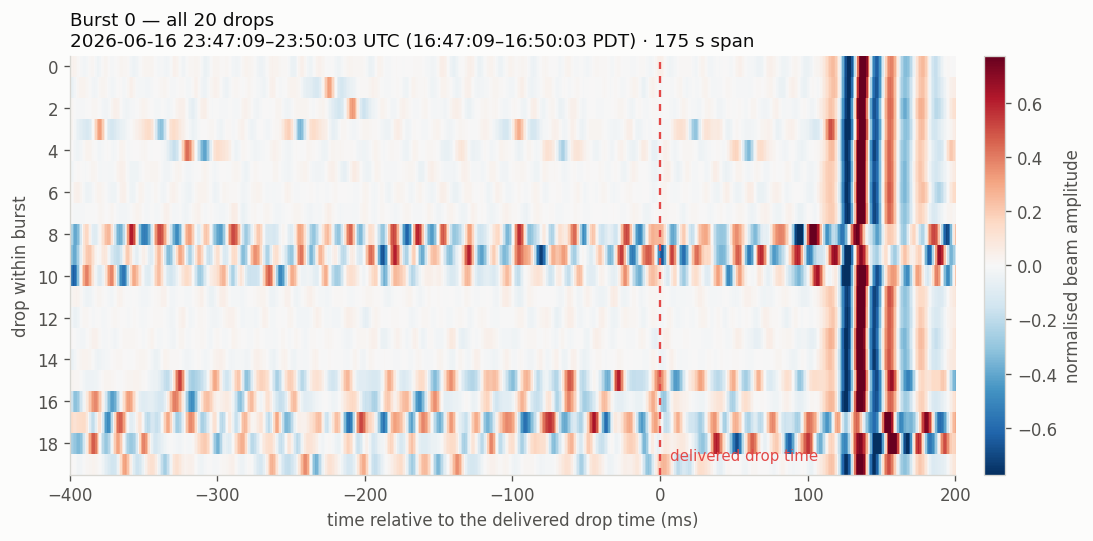

In [10]:
sel = np.where(bid == EXAMPLE_BURST)[0]
sel = sel[np.argsort(did[sel])]
img = np.array([beams[i] / np.max(np.abs(beams[i])) for i in sel])
lim = np.percentile(np.abs(img), 99)

fig, ax = plt.subplots(figsize=(9, 4.4), constrained_layout=True)
m = ax.imshow(img, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim,
              extent=[tau[0] * 1e3, tau[-1] * 1e3, len(sel) - 0.5, -0.5],
              interpolation="nearest", zorder=2)
ax.axvline(0, color=RED, lw=1.4, ls=(0, (3, 3)), zorder=5)
# Label sits at the BOTTOM of the axes, inside: the pre-arrival region is pale
# there, and the top edge is taken by the two-line title.
ax.annotate("delivered drop time", xy=(0, 0), xycoords=("data", "axes fraction"),
            xytext=(6, 7), textcoords="offset points", color=RED, fontsize=9,
            va="bottom", ha="left")

t0, t1 = btimes[sel[0]], btimes[sel[-1]]
ax.set_xlabel("time relative to the delivered drop time (ms)")
ax.set_ylabel("drop within burst")
ax.set_yticks(np.arange(0, len(sel), 2))   # integer: drop index is discrete
ax.grid(False)
fig.colorbar(m, ax=ax, pad=0.015, label="normalised beam amplitude")
ax.set_title(f"Burst {EXAMPLE_BURST} — all {len(sel)} drops\n"
             f"{t0:%Y-%m-%d %H:%M:%S}–{t1:%H:%M:%S} UTC "
             f"({t0 - dt.timedelta(hours=7):%H:%M:%S}–{t1 - dt.timedelta(hours=7):%H:%M:%S} PDT) · "
             f"{(t1 - t0).total_seconds():.0f} s span",
             color=INK, loc="left")
plt.show()

## 10. What to be careful about

- **The detection thresholds are descriptive.** NCC > 0.90 and SNR > 10 dB were
  chosen to make the flag reproducible, **not** pre-registered before looking.
  Do not quote the detected count as a tested detection rate.
- **Deep is a different story.** This notebook is Nano. On the Deep fibre the
  stacked drop/sham peak-SNR ratio is **1.017** overall — mostly not detected,
  with energy only in localised sections (strongest at fibre 200–664 m and
  706–1060 m). Those are **metres along fibre, not depth**; no depth
  registration exists for Deep.
- **The red line is the node pick, not the source instant.** ~90 ms absolute
  offset, measured against the check shot.
- **78.8 %** of the delivered picks have Max_CC < 0.9, and 5 drops disagree
  between the two nodes by ≥ 10 ms. Those rows are in `awd_drop_catalog.csv` and
  are worth dropping from any timing-critical stack.
- **The beam is phase-neutral by construction.** 30–60 Hz moveout at 2,975 m/s
  over 81–439 m, deliberately *not* called a P wave — see
  `nano_hierarchical_repeatability.py`.

Full detail, including the two-node timing comparison: `README.md` in this
directory.